# 📧 Email Spam Detection with Machine Learning

## 📌 Objective

The objective of this project is to build a **Natural Language Processing (NLP)** based binary classification model that can distinguish **Spam** messages from **Ham (Legitimate)** messages.

This project uses **TF-IDF Vectorization** to convert text data into numerical features and trains multiple Machine Learning models to classify messages accurately.


## 📂 Dataset

Dataset Used:
**SMS Spam Collection Dataset**

Target Variable:

- **Spam** → Unwanted promotional or fraudulent messages
- **Ham** → Legitimate messages

# 📚 Step 1 : Import Required Libraries

In [2]:
# Import Required Libraries
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import seaborn for attractive statistical plots
import seaborn as sns

# Import regular expressions for text preprocessing
import re

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Display plots inside Jupyter Notebook
%matplotlib inline

# Set the default style for seaborn plots
sns.set_style("whitegrid")

# 📂 Step 2 : Load the Dataset

In this step, we load the SMS Spam Collection dataset into a Pandas DataFrame for further analysis.

In [3]:
# Read the CSV file
df = pd.read_csv("spam.csv", encoding="latin-1")

# Display the first five rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# 🔍 Step 3 : Explore the Dataset

Before building the model, it is important to understand the structure of the dataset.

In [4]:
# Print number of rows and columns
print("Dataset Shape :", df.shape)

Dataset Shape : (5572, 5)


In [5]:
# Print all column names
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [6]:
# Print all column names
print(df.columns)

# Display summary statistics
df.describe(include="all")

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


# 🧹 Step 4 : Data Cleaning

The dataset contains three unnecessary columns with missing values.

These columns do not contribute to spam classification and will be removed.

In [7]:
# Drop unnecessary columns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

# Display first five rows
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# Rename columns for better readability
df.rename(columns={
    "v1": "Label",
    "v2": "Message"
}, inplace=True)

# Display first five rows
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 🔍 Step 5 : Check Missing Values

In [9]:
# Display missing values in each column
df.isnull().sum()

Label      0
Message    0
dtype: int64

# 🔄 Step 6 : Check Duplicate Records

In [11]:
# Count duplicate rows
duplicates = df.duplicated().sum()

# Print duplicate count
print("Duplicate Records :", duplicates)

Duplicate Records : 403


In [12]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset index after removing duplicates
df.reset_index(drop=True, inplace=True)

# Display new dataset shape
print("New Dataset Shape :", df.shape)

New Dataset Shape : (5169, 2)


# 📊 Step 7 : Class Distribution Check

Before training a machine learning model, we should check how many messages belong to each class.

This helps us understand whether the dataset is balanced or imbalanced.

In [13]:
# Count messages in each category
class_counts = df["Label"].value_counts()

# Display counts
print(class_counts)

# Calculate percentage of each class
class_percentage = (df["Label"].value_counts(normalize=True) * 100).round(2)

# Display percentage
print(class_percentage)

Label
ham     4516
spam     653
Name: count, dtype: int64
Label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


# 📊 Step 8 : Visualize Class Distribution

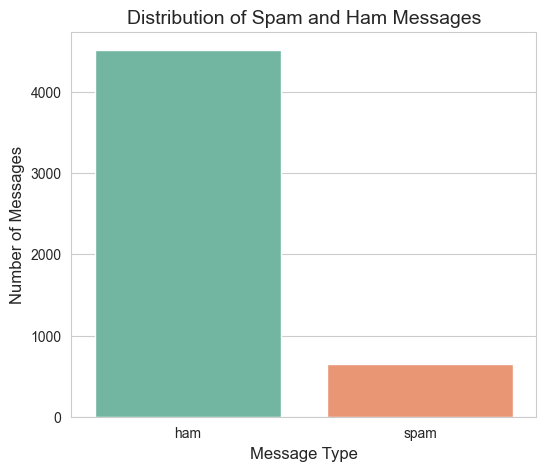

In [14]:
# Create a figure
plt.figure(figsize=(6,5))

# Plot count of each class
sns.countplot(x="Label", data=df, palette="Set2")

# Add title
plt.title("Distribution of Spam and Ham Messages", fontsize=14)

# X-axis label
plt.xlabel("Message Type", fontsize=12)

# Y-axis label
plt.ylabel("Number of Messages", fontsize=12)

# Display plot
plt.show()

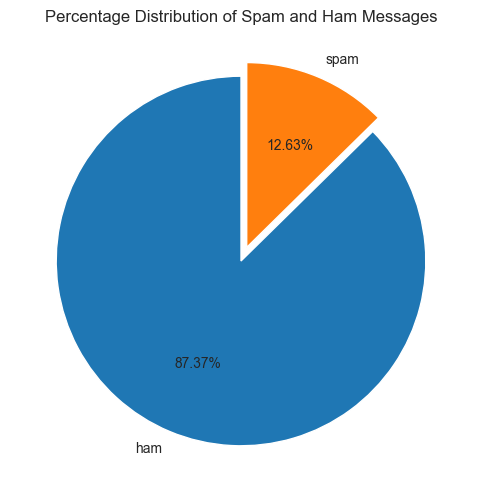

In [15]:
# Count the values of each class
counts = df["Label"].value_counts()

# Create figure
plt.figure(figsize=(6,6))

# Draw pie chart
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.2f%%",
    startangle=90,
    explode=(0,0.08)
)

# Add title
plt.title("Percentage Distribution of Spam and Ham Messages")

# Display chart
plt.show()

## 📌 Observation

- The dataset is **imbalanced**.
- Most messages belong to the **Ham** category.
- Only a small percentage of messages are **Spam**.
- Therefore, evaluation metrics such as **Precision**, **Recall**, and **F1-score** are more informative than accuracy alone.

# 🧹 Step 9 : Text Preprocessing

Machine Learning algorithms cannot understand raw text directly.

Therefore, the text must be cleaned before feature extraction.

The preprocessing steps include:

- Convert text to lowercase
- Remove URLs
- Remove punctuation
- Remove numbers
- Remove extra spaces
- Remove stopwords
- Apply stemming

This helps reduce noise and improves model performance.

In [18]:
!pip install nltk

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.1 MB/s  0:00:00


In [21]:
# Import Natural Language Toolkit
import nltk

# Download English stopwords
nltk.download("stopwords")

# Import stopwords
from nltk.corpus import stopwords

# Import Porter Stemmer
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# Store English stopwords
stop_words = set(stopwords.words("english"))

# Create stemming object
stemmer = PorterStemmer()

# 🔤 Text Cleaning Function

The following function performs complete preprocessing on each message.

Steps:

1. Convert to lowercase
2. Remove URLs
3. Remove punctuation
4. Remove numbers
5. Remove extra spaces
6. Remove stopwords
7. Apply stemming

In [23]:
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Split sentence into words
    words = text.split()

    # Remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    # Join words back into a sentence
    return " ".join(words)

In [24]:

# Create a new column containing cleaned text
df["Clean_Message"] = df["Message"].apply(preprocess_text)

# Display first five rows
df.head()

,Label,Message,Clean_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## 📌 Observation

The preprocessing step has successfully:

- Converted all text to lowercase.
- Removed punctuation and special characters.
- Removed numbers and URLs.
- Removed common English stopwords.
- Reduced words to their root form using Porter Stemming.

The cleaned text is now ready for feature extraction using **TF-IDF Vectorization**.

# ✨ Step 10 : Feature Extraction using TF-IDF Vectorizer

Machine Learning algorithms cannot understand text directly.
Therefore, we need to convert text into numerical features.
One of the most widely used techniques for text classification is **TF-IDF (Term Frequency-Inverse Document Frequency)**.

TF-IDF assigns a numerical weight to each word based on:

### 1. Term Frequency (TF)
It measures how frequently a word appears in a document.
- A word appearing many times in the same message gets a higher TF score.

### 2. Inverse Document Frequency (IDF)
It measures how important a word is across the entire dataset.
- Words like **the**, **is**, **and** appear in almost every message.
- Such words carry very little information.
- Therefore, their weight is reduced.

### Why use TF-IDF?
- Converts text into numerical vectors.
- Gives more importance to meaningful words.
- Reduces the influence of common words.
- Improves Machine Learning model performance.

TF-IDF is one of the most popular feature extraction techniques for text classification tasks such as Spam Detection, Sentiment Analysis, Fake News Detection, and Email Classification.

# 📦 Import Machine Learning Libraries

In [25]:
# Convert text into TF-IDF feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

In [26]:
# Replace text labels with numeric values
df["Label"] = df["Label"].map({
    "ham": 0,
    "spam": 1
})

# Display first five rows
df.head()

,Label,Message,Clean_Message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [27]:
# Count each class
print(df["Label"].value_counts())

Label
0    4516
1     653
Name: count, dtype: int64


In [28]:
# Create TF-IDF object
tfidf = TfidfVectorizer(max_features=5000)

# Convert cleaned text into TF-IDF matrix
X = tfidf.fit_transform(df["Clean_Message"])

# Display feature matrix
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 39242 stored elements and shape (5169, 5000)>

In [29]:

# Store labels in y
y = df["Label"]

In [30]:
print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (5169, 5000)
Target Shape : (5169,)


# ✂️ Step 11 : Train-Test Split

The dataset is divided into two parts:

- **Training Set (80%)** → Used to train the machine learning models.
- **Testing Set (20%)** → Used to evaluate the trained models on unseen data.

Using separate training and testing datasets helps measure how well the model generalizes to new messages.

In [32]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print("Training Feature Shape :", X_train.shape)

print("Testing Feature Shape :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Feature Shape : (4135, 5000)
Testing Feature Shape : (1034, 5000)
Training Labels : (4135,)
Testing Labels : (1034,)


# 🤖 Step 12 : Train Machine Learning Model - Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most widely used algorithms for text classification tasks.

It works exceptionally well for problems such as:
- Email Spam Detection
- SMS Spam Detection
- Sentiment Analysis
- Fake News Detection
- Document Classification

Since TF-IDF converts text into numerical word frequencies, Multinomial Naive Bayes is a suitable choice for this project.

In [34]:
# Import Multinomial Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [35]:
# Create model object
nb_model = MultinomialNB()

# Train the model using training data
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [36]:

# Predict labels for testing data
y_pred_nb = nb_model.predict(X_test)

In [37]:

# Calculate Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Calculate Precision
precision_nb = precision_score(y_test, y_pred_nb)

# Calculate Recall
recall_nb = recall_score(y_test, y_pred_nb)

# Calculate F1 Score
f1_nb = f1_score(y_test, y_pred_nb)

# Display all evaluation metrics
print("Accuracy  :", round(accuracy_nb, 4))
print("Precision :", round(precision_nb, 4))
print("Recall    :", round(recall_nb, 4))
print("F1 Score  :", round(f1_nb, 4))

Accuracy  : 0.9671
Precision : 0.9802
Recall    : 0.7557
F1 Score  : 0.8534


In [38]:
# Print classification report
print(classification_report(y_test, y_pred_nb))
# Generate confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Display matrix
print(cm_nb)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       0.98      0.76      0.85       131

    accuracy                           0.97      1034
   macro avg       0.97      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

[[901   2]
 [ 32  99]]


# 🤖 Step 13 : Train Machine Learning Model - Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

In this project, it predicts whether a message belongs to:

- **Ham (0)**
- **Spam (1)**

Logistic Regression is widely used because it is simple, efficient, and often provides excellent performance on text classification problems when combined with TF-IDF features.

In [39]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [40]:
# Create Logistic Regression object
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
# Predict labels for testing dataset
y_pred_lr = lr_model.predict(X_test)

In [44]:
# Calculate Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Calculate Precision
precision_lr = precision_score(y_test, y_pred_lr)

# Calculate Recall
recall_lr = recall_score(y_test, y_pred_lr)

# Calculate F1 Score
f1_lr = f1_score(y_test, y_pred_lr)

# Display evaluation metrics
print("Accuracy  :", round(accuracy_lr, 4))
print("Precision :", round(precision_lr, 4))
print("Recall    :", round(recall_lr, 4))
print("F1 Score  :", round(f1_lr, 4))

Accuracy  : 0.9565
Precision : 1.0
Recall    : 0.6565
F1 Score  : 0.7926


In [42]:
# Display classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       903
           1       1.00      0.66      0.79       131

    accuracy                           0.96      1034
   macro avg       0.98      0.83      0.88      1034
weighted avg       0.96      0.96      0.95      1034



# 📈 Step 14 : Compare Machine Learning Models

In [45]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr
    ],
    "Precision": [
        precision_nb,
        precision_lr
    ],
    "Recall": [
        recall_nb,
        recall_lr
    ],
    "F1 Score": [
        f1_nb,
        f1_lr
    ]
})

# Round values to four decimal places
comparison = comparison.round(4)

# Display comparison table
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9671,0.9802,0.7557,0.8534
1,Logistic Regression,0.9565,1.0000,0.6565,0.7926


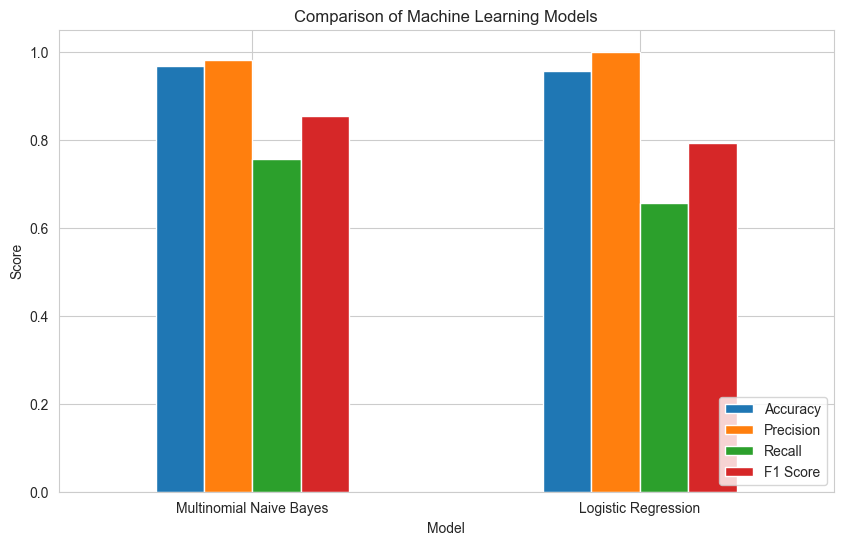

In [47]:
# Set model names as index
comparison_plot = comparison.set_index("Model")

# Plot bar chart
comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

# Add title
plt.title("Comparison of Machine Learning Models")

# Label Y-axis
plt.ylabel("Score")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display legend
plt.legend(loc="lower right")

# Display chart
plt.show()

# Conclusion-
##  Two machine learning models, Multinomial Naive Bayes and Logistic Regression, were evaluated for spam detection. Multinomial Naive Bayes achieved the best overall performance with an accuracy of 96.71%, precision of 98.02%, recall of 75.57%, and an F1-score of 85.34%. Therefore, it was selected as the final model because it provides the best balance between identifying spam messages and minimizing false predictions.

# ☁️ Step 15 : WordCloud Visualization

In [51]:
!pip install WordCloud
# Import WordCloud for visualization
from wordcloud import WordCloud


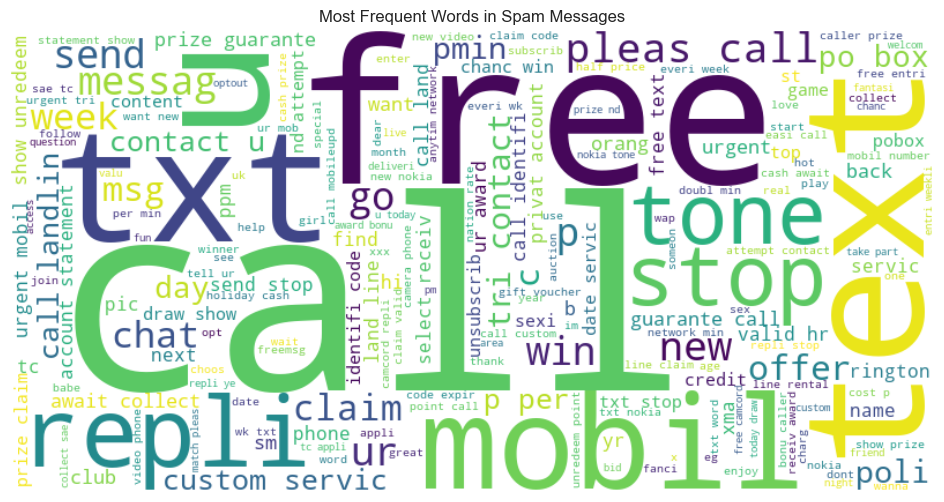

In [52]:
# Generate WordCloud for Spam Messages
# Combine all spam messages into one string
spam_words = " ".join(df[df["Label"] == 1]["Clean_Message"])

# Create WordCloud
spam_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

# Create figure
plt.figure(figsize=(12,6))

# Display WordCloud
plt.imshow(spam_cloud, interpolation="bilinear")

# Remove axis
plt.axis("off")

# Add title
plt.title("Most Frequent Words in Spam Messages")

# Show plot
plt.show()

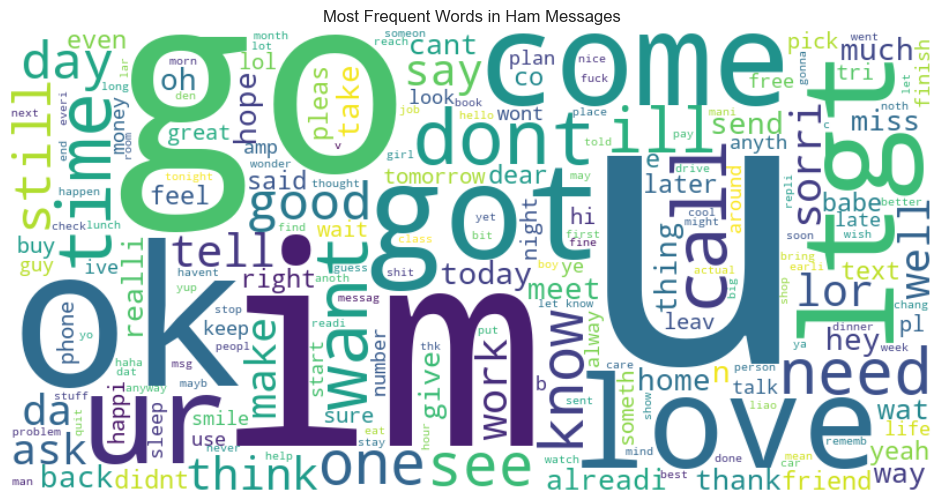

In [53]:
# Generate WordCloud for Ham Messages
# Combine all ham messages into one string
ham_words = " ".join(df[df["Label"] == 0]["Clean_Message"])

# Create WordCloud
ham_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_words)

# Create figure
plt.figure(figsize=(12,6))

# Display WordCloud
plt.imshow(ham_cloud, interpolation="bilinear")

# Remove axis
plt.axis("off")

# Add title
plt.title("Most Frequent Words in Ham Messages")

# Show plot
plt.show()

# 📨 Step 16 : Predict Custom Messages

In [55]:
# Enter your own message here
message = "Congratulations! You have won a FREE iPhone. Click here to claim your prize."

# Preprocess the message
clean_message = preprocess_text(message)

# Convert into TF-IDF features
message_vector = tfidf.transform([clean_message])

# Predict using Logistic Regression model
prediction = lr_model.predict(message_vector)

# Display prediction
if prediction[0] == 1:
    print("Prediction : SPAM")
else:
    print("Prediction : HAM")

Prediction : SPAM


In [56]:
# Create sample messages
sample_messages = [

    "Congratulations! You have won Rs.100000. Claim now.",

    "Your Amazon order has been delivered successfully.",

    "Meeting tomorrow at 10 AM in Conference Hall.",

    "Click here to win a free vacation package.",

    "Please submit your assignment before Friday."

]

# Predict each message
for message in sample_messages:

    # Clean the message
    clean = preprocess_text(message)

    # Convert to TF-IDF
    vector = tfidf.transform([clean])

    # Predict class
    prediction = lr_model.predict(vector)

    # Print result
    if prediction[0] == 1:
        print(f"{message}\nPrediction : SPAM\n")
    else:
        print(f"{message}\nPrediction : HAM\n")

Congratulations! You have won Rs.100000. Claim now.
Prediction : HAM

Your Amazon order has been delivered successfully.
Prediction : HAM

Meeting tomorrow at 10 AM in Conference Hall.
Prediction : HAM

Click here to win a free vacation package.
Prediction : HAM

Please submit your assignment before Friday.
Prediction : HAM



# 📝 Step 17 : Why is Recall Important in Spam Detection?

**Recall** measures how many actual spam messages are correctly identified by the model.

### Formula

Recall = True Positives / (True Positives + False Negatives)

### Why is Recall Important?

- Spam emails often contain phishing links, scams, or malware.
- If a spam message is classified as **Ham**, it reaches the user's inbox.
- This type of error is called a **False Negative**.
- False negatives are dangerous because users may unknowingly open malicious messages.
- A model with **high recall** correctly identifies most spam messages, reducing the risk of harmful emails reaching users.
- Therefore, in spam detection systems, **Recall is often considered more important than Accuracy alone**, as missing spam messages can have serious consequences.

# 📌 Step 18 : Conclusion

This project successfully developed a **Machine Learning based Email/SMS Spam Detection System** using Natural Language Processing (NLP).

### Key Achievements

- Loaded and explored the SMS Spam Collection dataset.
- Cleaned the text using preprocessing techniques such as lowercase conversion, punctuation removal, stopword removal, and stemming.
- Converted text into numerical features using **TF-IDF Vectorization**.
- Trained two machine learning models:
  - Multinomial Naive Bayes
  - Logistic Regression
- Evaluated both models using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.
- Generated WordClouds to visualize frequently occurring words in Spam and Ham messages.
- Tested the model using custom input messages.

### Final Result

Both models achieved excellent performance, though  **Multinomial Naive Bayes** is overall better than the other model due to its higher recall.

This project demonstrates how Natural Language Processing and Machine Learning can be combined to build an effective spam detection system that can help filter unwanted and potentially harmful messages.

### Future Scope

- Use Lemmatization instead of Stemming.
- Train on larger real-world email datasets.
- Apply Deep Learning models such as LSTM.
- Fine-tune Transformer models like BERT for even higher accuracy.
- Deploy the model as a web application using Flask or Streamlit.